In [1]:
import pandas as pd
import warnings
import numpy as np
warnings.filterwarnings("ignore")

## Estrazione dati da MongoDB

In [2]:
from pymongo import MongoClient
from dotenv import load_dotenv
import os

In [112]:
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

client = MongoClient(MONGO_URI)
db=client["PolymerPrediction"]
collection=db["extendedPolymers"]

#print(collection.count_documents({}))

In [122]:
docs = list(collection.find({}))
df = pd.DataFrame(docs)

# espando il dizionario "properties"
prop_df = pd.json_normalize(df["properties"])

# integro nel dataframe
df = pd.concat([df.drop(columns=["properties"]), prop_df], axis=1)

target="Tc"
# rimuovo righe senza SMILES o target
df = df.dropna(subset=["smiles", target])
df = df[~df["smiles"].str.contains(r"\[\[", na=False)].copy()

df.head()

,_id,polymer_name,smiles,bigsmiles,source_dataset,Tg,density,Tc,glass_cte,rubber_cte
0,696fbfb5e39f4ce4bdda8113,None,*/C=C/C1CC(*)C2C(=O)N(CCCCCC)C(=O)C12,None,extendedPolymers,NaN,1.035218,0.232246,None,None
1,696fbfb5e39f4ce4bdda811e,None,*C(*)C(=O)OC(C)C,None,extendedPolymers,NaN,1.034629,0.218613,None,None
2,696fbfb5e39f4ce4bdda812a,None,*C(=O)NCCNC(=O)c1ccc(N2C(=O)c3ccc(*)cc3C2=O)cc1,None,extendedPolymers,NaN,1.289378,0.262578,None,None
3,696fbfb5e39f4ce4bdda814e,None,*C(=O)c1ccc2c(c1)C(=O)N(c1ccc(N3C(=O)c4ccc(*)c...,None,extendedPolymers,NaN,1.281941,0.293058,None,None
4,696fbfb5e39f4ce4bdda816a,None,*C(C(*)OCC)C,None,extendedPolymers,NaN,0.920916,0.227849,None,None


## Integrazione descrittori RDKit

In [123]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np

descriptor_names = [desc[0] for desc in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
# print(descriptor_names)

def rdkit_descr(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return {d: np.nan for d in descriptor_names}
    values = calc.CalcDescriptors(mol)
    return dict(zip(descriptor_names, values))

desc_df = df["smiles"].apply(rdkit_descr).apply(pd.Series)
desc_df.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,12.611295,12.611295,0.019051,0.019051,0.534172,37.277778,247.338,226.170,247.157229,98.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
1,10.856019,10.856019,0.093796,0.093796,0.479209,13.714286,100.117,92.053,100.052429,40.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,12.632256,12.632256,0.051149,-0.359150,0.619410,13.840000,335.319,322.215,335.090606,124.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,12.882030,12.882030,0.039699,-0.555202,0.623381,15.866667,395.330,386.258,395.054220,142.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.476852,5.476852,0.468102,0.468102,0.502023,24.333333,86.134,76.054,86.073165,36.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


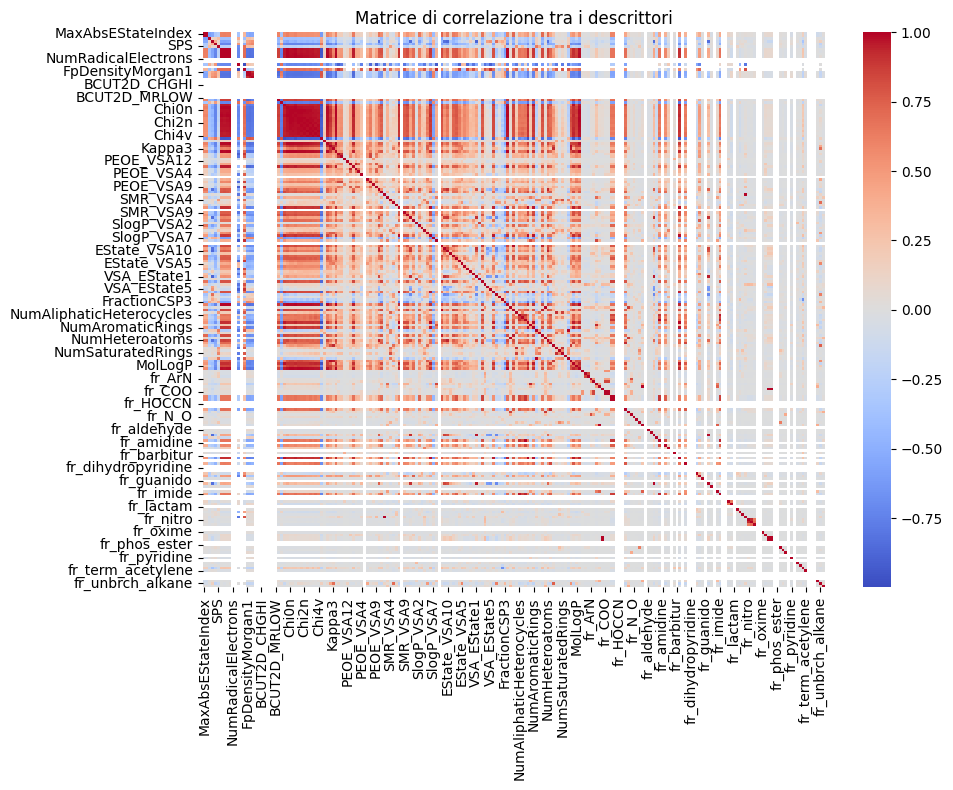

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = desc_df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra i descrittori")
plt.tight_layout()
plt.show()

## Aggiunta Fingerprint

In [125]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def morgan_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*1024
    fp = morgan_gen.GetFingerprint(mol)  
    return list(fp)

fp_df = df["smiles"].apply(morgan_fp).apply(pd.Series)
fp_df.columns = [f"fp_{i}" for i in range(fp_df.shape[1])]

In [126]:
from rdkit.Chem import MACCSkeys

def maccs_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*167  # MACCS ha 167 bit (indice 0 inutilizzato)
    fp = MACCSkeys.GenMACCSKeys(mol)
    return list(fp)
maccs_df = df["smiles"].apply(maccs_fp).apply(pd.Series)
maccs_df.columns=[f"maccs_{i}" for i in range(167)]

feature_df = pd.concat([desc_df, fp_df, maccs_df], axis=1)

## Pulizia dei dati

In [127]:
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
feature_df = feature_df.fillna(feature_df.median(numeric_only=True))
feature_df = feature_df.dropna(axis=1, how="all")

# rimuovo colonne costanti (con varianza 0) 
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.0)
sel.fit(feature_df)

mask = sel.get_support()
feature_df = feature_df.loc[:, mask]

print("Shape:", feature_df.shape[1])

Shape: 1291


## Preparazione dataset (separazione target)

In [128]:
y = df[target]
X = feature_df.copy()
X.index = df["_id"]
print("Shape X:", X.shape)
print("Shape y:", y.shape)
X.sample(10)

import numpy as np

X_np = np.ascontiguousarray(X.to_numpy(), dtype=np.float32)

print("dtype:", X_np.dtype)
print("contiguous:", X_np.flags['C_CONTIGUOUS'])
print("finite:", np.isfinite(X_np).all())
print("max abs:", np.max(np.abs(X_np)))


Shape X: (1070, 1291)
Shape y: (1070,)
dtype: float32
contiguous: True
finite: True
max abs: 3.9950698e+21


## Calcolo deviazione standard

In [129]:
std = y.std(ddof=1)
print(y.min(), y.max())
print(f"Deviazione standard {target}: {std:.4f}")


0.082200976 0.618759937
Deviazione standard Tc: 0.0656
